# Can Satellite Data Predict Socioeconomic Development Across Indian Districts?

**Author:** Anjana K S  

## Research question

Can satellite data such as nighttime lights, vegetation cover, built-up area, and elevation predict household wealth across Indian districts?

Satellite data offers a scalable, low-cost alternative to household surveys for tracking development outcomes. If nighttime light intensity and land-use patterns are strong predictors of wealth, policymakers could use remote sensing to fill data gaps in
districts where survey coverage is lower.

## Data sources

| Source | Variable | Extracted via |
|--------|----------|---------------|
| NOAA VIIRS DNB Monthly V1 | Nighttime light radiance (`avg_rad`), cloud-free coverage (`cf_cvg`) | Google Earth Engine |
| MODIS MOD13Q1 | NDVI (vegetation index) | Google Earth Engine |
| USGS SRTM | Elevation (metres) | Google Earth Engine |
| Google Dynamic World V1 | Built-up area fraction | Google Earth Engine |
| NFHS-5 (2019–21) Couples Recode | District-level wealth, financial inclusion, empowerment, literacy, urbanisation | Aggregated from microdata (~57,000 households) |

Satellite features were extracted at district level using `reduceRegions()` in Google Earth Engine
and merged with NFHS-5 survey aggregates via the Census 2011 district identifier (`pc11_d_id`).

## Workflow overview

1. Extract satellite features for all Indian districts using Google Earth Engine (see `gee_scripts/`)
2. Aggregate NFHS-5 household data to district level
3. Merge satellite and survey datasets on district ID
4. Correlations and distributions
5. Model progression: Linear Regression, Random Forest, XGBoost
6. Feature importance analysis
7. Robustness check: remove cloud-free coverage to test data quality confounding

## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

# Reproducibility
SEED = 42


## Loading Data

The satellite CSVs were exported from Google Earth Engine to Google Drive. Update the paths below to match your local directory after downloading the files.

The NFHS-5 file is a cleaned couples recode derived from the official NFHS-5 microdata.

In [8]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Setting Directory and Loading Data
DATA_DIR = "/content/drive/MyDrive/Night_Lights_Project/"

night  = pd.read_csv(DATA_DIR + "district_nightlights_2021.csv")
ndvi   = pd.read_csv(DATA_DIR + "district_ndvi_2021.csv")
elev   = pd.read_csv(DATA_DIR + "district_elevation.csv")
built  = pd.read_csv(DATA_DIR + "district_builtup.csv")
nfhs   = pd.read_stata(DATA_DIR + "NFHS_data.DTA", convert_categoricals=False)

print("Rows loaded:")
print(f"  nightlights : {len(night)}")
print(f"  ndvi        : {len(ndvi)}")
print(f"  elevation   : {len(elev)}")
print(f"  built-up    : {len(built)}")
print(f"  nfhs        : {len(nfhs)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows loaded:
  nightlights : 641
  ndvi        : 641
  elevation   : 641
  built-up    : 641
  nfhs        : 55124



## Prepare and merge satellite features

Each GEE export gives a CSV with a `mean` column and a district identifier (`pc11_d_id`).
We rename `mean` to a descriptive variable name, keep only the columns we need,
then join all four satellite datasets using `pc11_d_id`.

In [4]:
# Rename and select columns
ndvi  = ndvi.rename(columns={"mean": "ndvi"}  )[["pc11_d_id", "ndvi"]]
elev  = elev.rename(columns={"mean": "elevation"})[["pc11_d_id", "elevation"]]
built = built.rename(columns={"mean": "builtup"})[["pc11_d_id", "builtup"]]

# Nightlights already has named columns: avg_rad, cf_cvg
night = night[["pc11_d_id", "avg_rad", "cf_cvg"]]

# Merge all satellite layers
sat = (
    night
    .merge(ndvi,  on="pc11_d_id", how="inner")
    .merge(elev,  on="pc11_d_id", how="inner")
    .merge(built, on="pc11_d_id", how="inner")
)

print(f"Satellite panel shape: {sat.shape}")
print(f"Columns: {sat.columns.tolist()}")

Satellite panel shape: (641, 6)
Columns: ['pc11_d_id', 'avg_rad', 'cf_cvg', 'ndvi', 'elevation', 'builtup']



## Aggregate NFHS-5 to district level

The NFHS-5 couples recode is individual-level data (~57,000 households).
We aggregate to district level by taking means of the key outcome and
socioeconomic variables, grouped on `sdist` (the NFHS district code,
which maps to `pc11_d_id` from the Census 2011 classification).

In [5]:
district_nfhs = (
    nfhs
    .groupby("sdist")
    .agg(
        wealth          = ("wealth",          "mean"),
        literacy_w      = ("literacy_w",      "mean"),
        fin_inclusion_w = ("fin_inclusion_w",  "mean"),
        empower_index   = ("empower_index",   "mean"),
        urban           = ("urban",           "mean"),
    )
    .reset_index()
)

print(f"Districts in NFHS: {len(district_nfhs)}")
district_nfhs.head()

Districts in NFHS: 707


,sdist,wealth,literacy_w,fin_inclusion_w,empower_index,urban
0,1,3.168421,0.189474,0.535088,0.813158,0.094737
1,2,3.051282,0.115385,0.534188,0.618590,0.115385
2,3,3.328767,0.219178,0.644977,0.671233,0.273973
3,4,2.609756,0.097561,0.575203,0.664634,0.121951
4,5,3.036144,0.204819,0.507028,0.710843,0.084337



## Merge satellite and survey data

We join on the district identifier. The satellite data uses `pc11_d_id` and the NFHS aggregates use `sdist`. These are the same Census 2011 district codes, just named differently across the two sources.

In [6]:
final_df = pd.merge(
    sat,
    district_nfhs,
    left_on  = "pc11_d_id",
    right_on = "sdist",
    how      = "inner"
)

print(f"Final dataset shape: {final_df.shape}")
print(f"Districts matched: {len(final_df)} out of {len(sat)} satellite districts")

Final dataset shape: (575, 12)
Districts matched: 575 out of 641 satellite districts



## Exploratory data analysis

### 1) Correlation matrix

What to look for:
- How strongly does `avg_rad` (nightlights) correlate with `wealth`?
- Does `cf_cvg` (cloud-free coverage, a data quality variable) correlate
  with outcomes? If so, it may confound the nightlights signal.
- How does `builtup` compare to `avg_rad` as a proxy for urbanisation?

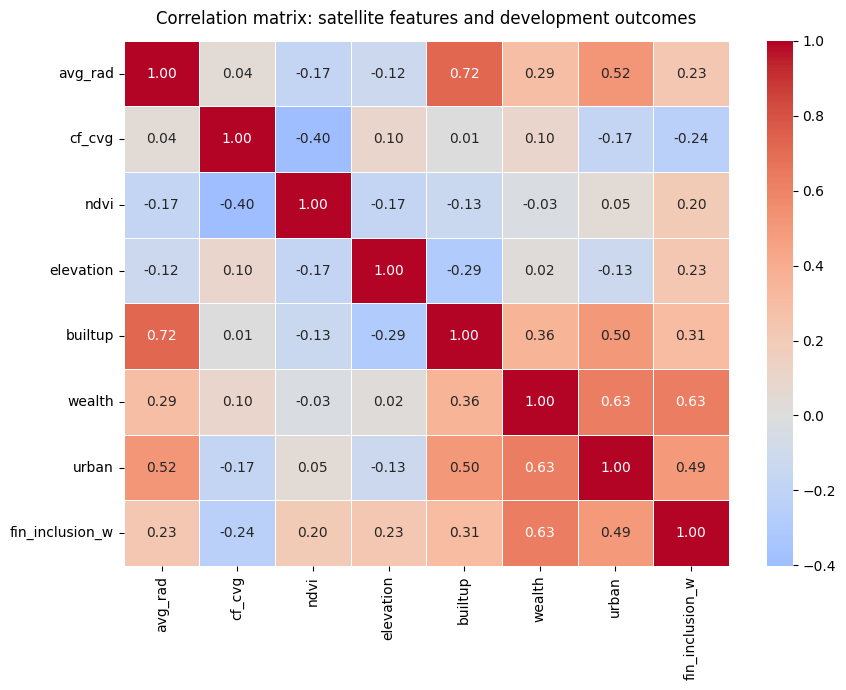


Nightlights (avg_rad) correlations with outcomes:
                 avg_rad
wealth             0.291
urban              0.520
fin_inclusion_w    0.229


In [10]:
analysis_vars = [
    "avg_rad", "cf_cvg", "ndvi", "elevation", "builtup",
    "wealth", "urban", "fin_inclusion_w"
]

corr = final_df[analysis_vars].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot    = True,
    fmt      = ".2f",
    cmap     = "coolwarm",
    center   = 0,
    linewidths = 0.5,
    ax       = ax
)
ax.set_title("Correlation matrix: satellite features and development outcomes", pad=12)
plt.tight_layout()
plt.show()

print("\nNightlights (avg_rad) correlations with outcomes:")
print(corr.loc[["avg_rad"], ["wealth", "urban", "fin_inclusion_w"]].T)

### 2) Scatter: nightlights vs wealth

The scatter plot shows the relationship before modelling.
We expect a positive but noisy association, i.e., nightlights are a proxy for economic activity but are affected by clouds, urban glow spill, and geography, which is why we add NDVI, elevation, and built-up area.

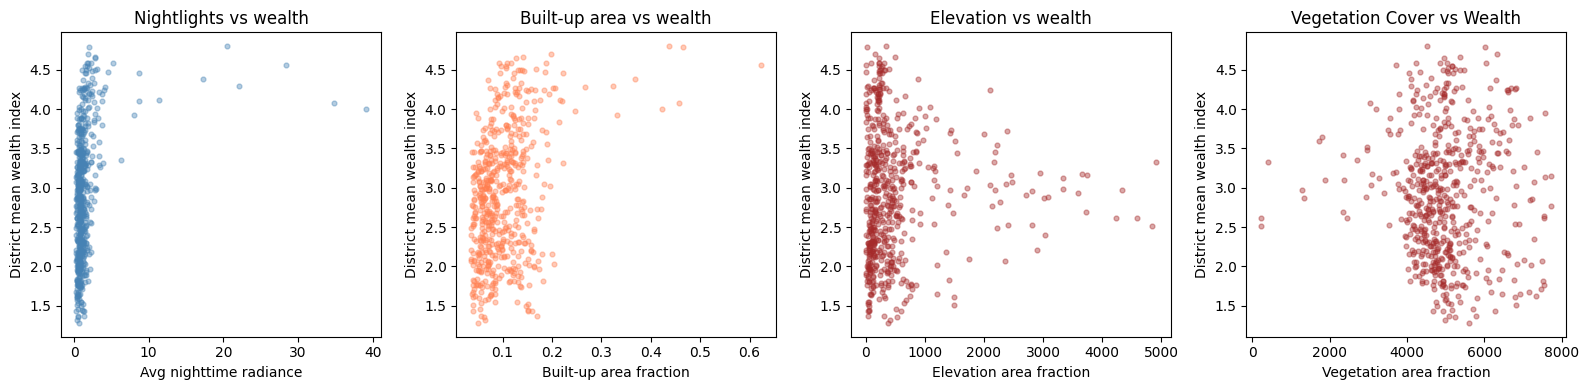

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Nightlights vs wealth
axes[0].scatter(final_df["avg_rad"], final_df["wealth"], alpha=0.4, s=12, color="steelblue")
axes[0].set_xlabel("Avg nighttime radiance")
axes[0].set_ylabel("District mean wealth index")
axes[0].set_title("Nightlights vs wealth")

# Built-up vs wealth
axes[1].scatter(final_df["builtup"], final_df["wealth"], alpha=0.4, s=12, color="coral")
axes[1].set_xlabel("Built-up area fraction")
axes[1].set_ylabel("District mean wealth index")
axes[1].set_title("Built-up area vs wealth")

# Elevation vs wealth
axes[2].scatter(final_df["elevation"], final_df["wealth"], alpha=0.4, s=12, color="brown")
axes[2].set_xlabel("Elevation area fraction")
axes[2].set_ylabel("District mean wealth index")
axes[2].set_title("Elevation vs wealth")

# ndvi vs wealth
axes[3].scatter(final_df["ndvi"], final_df["wealth"], alpha=0.4, s=12, color="brown")
axes[3].set_xlabel("Vegetation area fraction")
axes[3].set_ylabel("District mean wealth index")
axes[3].set_title("Vegetation Cover vs Wealth")

plt.tight_layout()
plt.show()


## Modelling

We predict district-level household wealth using five satellite features. Three models are estimated:

1. **Linear Regression**: baseline, assumes linear, additive relationships
2. **Random Forest**: captures non-linearities and feature interactions
3. **XGBoost**: gradient-boosted trees; generally highest performance

We use an 80/20 train-test split with `random_state=42` for reproducibility. Performance is evaluated using R².

In [12]:
FEATURES = ["avg_rad", "cf_cvg", "ndvi", "elevation", "builtup"]
TARGET   = "wealth"

X = final_df[FEATURES]
y = final_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set: {X_train.shape[0]} districts")
print(f"Test set:     {X_test.shape[0]} districts")

Training set: 460 districts
Test set:     115 districts


### 1. Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
print(f"Linear Regression  R² = {r2_lr:.4f}")

Linear Regression  R² = 0.2183


### 2. Random Forest


In [14]:
rf = RandomForestRegressor(n_estimators=500, random_state=SEED)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
print(f"Random Forest      R² = {r2_rf:.4f}")

Random Forest      R² = 0.7227


### 3. XGBoost

XGBoost builds trees sequentially, each correcting the errors of the previous. We use `max_depth=4` and `learning_rate=0.05` to avoid overfitting on a relatively small district-level dataset (~575 observations).

In [15]:
xgb = XGBRegressor(
    n_estimators  = 500,
    max_depth     = 4,
    learning_rate = 0.05,
    random_state  = SEED
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)
print(f"XGBoost            R² = {r2_xgb:.4f}")

XGBoost            R² = 0.6517


### Results

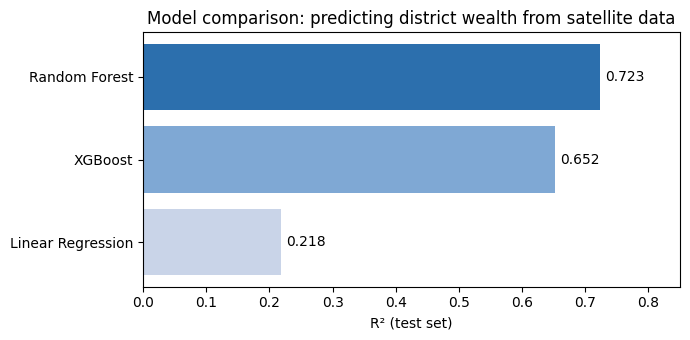

            Model       R²
Linear Regression 0.218307
          XGBoost 0.651711
    Random Forest 0.722672


In [17]:
import os

results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Random Forest"],
    "R²":    [r2_lr, r2_xgb, r2_rf]
}).sort_values("R²")

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(results["Model"], results["R²"], color=["#c9d4e8", "#7fa8d4", "#2c6fad"])
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0, 0.85)
ax.set_xlabel("R² (test set)")
ax.set_title("Model comparison: predicting district wealth from satellite data")
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs("../outputs/", exist_ok=True)
plt.savefig("../outputs/model_comparison.png", dpi=150)
plt.show()

print(results.to_string(index=False))


## Feature importance

Random Forest assigns each feature an importance score based on how much it reduces prediction error across all trees.

**Key finding:** `cf_cvg` (cloud-free coverage) ranks as the most important feature at 0.49 which is higher than nightlights themselves. This is a data quality variable, not a development indicator. Higher cloud-free coverage means more
reliable nighttime light readings, but it also correlates geographically with arid/semi-arid regions (like Rajasthan) that have unique development patterns. This leads us to do a robustness check.

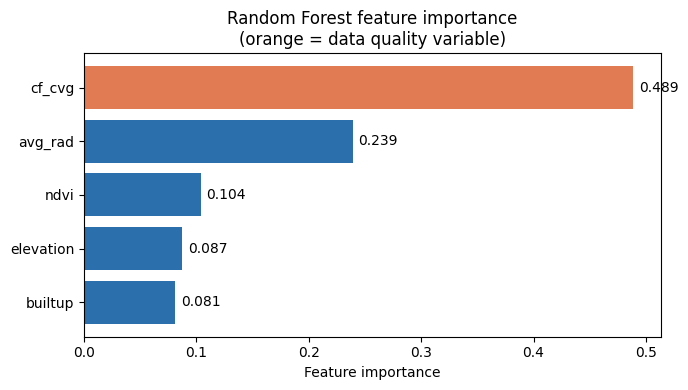

  feature  importance
   cf_cvg    0.488676
  avg_rad    0.239187
     ndvi    0.103665
elevation    0.087230
  builtup    0.081242


In [18]:
imp = (
    pd.DataFrame({"feature": FEATURES, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#e07b54" if f == "cf_cvg" else "#2c6fad" for f in imp["feature"]]
bars = ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=colors[::-1])
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest feature importance\n(orange = data quality variable)")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

print(imp.to_string(index=False))

## Robustness check: removing cloud-free coverage

Since `cf_cvg` is a data quality variable (proportion of cloud-free observations in the VIIRS monthly composite), its high importance could reflect geographic confounding rather than a genuine development signal.

Hence, we re-run Random Forest without `cf_cvg` to assess how much of the predictive power survives on purely physical satellite signals.

We expect R² to drop, but if nightlights, NDVI, elevation, and built-up area are actually predictive, the model should still perform better than the linear baseline.

In [21]:
FEATURES_NO_CF = ["avg_rad", "ndvi", "elevation", "builtup"]

X2 = final_df[FEATURES_NO_CF]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=SEED
)

rf2 = RandomForestRegressor(n_estimators=500, random_state=SEED)
rf2.fit(X2_train, y2_train)
pred_rf2 = rf2.predict(X2_test)
r2_rf2 = r2_score(y2_test, pred_rf2)

print("Robustness check — Random Forest without cf_cvg")
print(f"  R² with cf_cvg : {r2_rf:.4f}")
print(f"  R² without cf_cvg : {r2_rf2:.4f}")
print(f"  Drop in R² : {r2_rf - r2_rf2:.4f}")
print()
print("Interpretation: the drop suggests cf_cvg captures geographic patterns")
print("beyond pure data quality. The remaining R² = {:.2f} reflects genuine".format(r2_rf2))
print("satellite-to-wealth predictive signal from nightlights, vegetation,")
print("elevation, and built-up area alone.")

Robustness check — Random Forest without cf_cvg
  R² with cf_cvg : 0.7227
  R² without cf_cvg : 0.4707
  Drop in R² : 0.2520

Interpretation: the drop suggests cf_cvg captures geographic patterns
beyond pure data quality. The remaining R² = 0.47 reflects genuine
satellite-to-wealth predictive signal from nightlights, vegetation,
elevation, and built-up area alone.



## Summary of findings

| Model | Features | R² |
|-------|----------|----|
| Linear Regression | all 5 | 0.218 |
| XGBoost | all 5 | 0.652 |
| Random Forest | all 5 | **0.723** |
| Random Forest | excl. cf_cvg | 0.471 |

**Finding 1 — Non-linear models outperform the linear baseline.**
The jump from R² = 0.22 (linear) to R² = 0.72 (Random Forest) indicates that
the relationship between satellite proxies and wealth is non-linear and
involves feature interactions that tree-based models can capture.

**Finding 2 — Cloud-free coverage (cf_cvg) is the top predictor (importance = 0.49).**
This is a VIIRS data quality flag, not a direct development signal. Its dominance
suggests it proxies for geographic patterns (e.g. arid vs humid districts) that
co-vary with wealth. Removing it drops R² from 0.72 to 0.47.

**Finding 3 — Nightlights remain the second most important feature (0.24) even
after controlling for geography via the other satellite layers.**

**Limitations:**
- Aggregating household survey data to district level reduces the
sample to ~575 district-year observations.
- Results should be interpreted as
district-level associations, not causal estimates.



In [22]:
# Export the final merged dataset
final_df.to_csv("../outputs/india_satellite_development_district.csv", index=False)
print("Exported: outputs/india_satellite_development_district.csv")
print(f"Shape: {final_df.shape}")

Exported: outputs/india_satellite_development_district.csv
Shape: (575, 12)
